## Historical experiment — maintained workflow available
This notebook is preserved with its original code and outputs. Its environment-specific paths, preprocessing/split choices and legacy APIs are historical evidence, not the supported reproduction path.
Use [report_workflow.ipynb](report_workflow.ipynb) for the runnable preparation, real neural/regression training, validation, saved evaluation and inference workflow. See [report coverage](../REPORT_COVERAGE.md) for differences and unverified historical results.

In [ ]:
from google.colab  import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
import sys
sys.path.append('/content/gdrive/MyDrive/pythonlib_rnn')

import pandas as pd
import numpy as np
from math import sqrt
from numpy import concatenate
from matplotlib import pyplot
from pandas import read_csv
from pandas import DataFrame
from pandas import concat
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import LSTM, GRU
import tensorflow as tf
from datetime import datetime

In [ ]:
file = "/content/gdrive/MyDrive/pythonlib/household_power_consumption.csv"
dataset = read_csv(file,
                   parse_dates={'dt' : ['Date', 'Time']},
                   infer_datetime_format=True, 
                   index_col= 0,
                   na_values=['nan','?'],
                   sep=';')
dataset.fillna(0, inplace=True)
values = dataset.values
# ensure all data is float
values = values.astype('float32')

In [ ]:
dataset.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
dt,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2075259 entries, 2006-12-16 17:24:00 to 2010-11-26 21:02:00
Data columns (total 7 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Global_active_power    float64
 1   Global_reactive_power  float64
 2   Voltage                float64
 3   Global_intensity       float64
 4   Sub_metering_1         float64
 5   Sub_metering_2         float64
 6   Sub_metering_3         float64
dtypes: float64(7)
memory usage: 126.7 MB


In [ ]:
# normalizing input features
scaler = MinMaxScaler(feature_range=(0, 1))
scaled = scaler.fit_transform(values)
scaled =pd.DataFrame(scaled)

In [ ]:
scaled.shape

(2075259, 7)

In [ ]:


def create_ts_data(dataset, lookback=1, predicted_col=1):
    temp=dataset.copy()
    temp["id"]= range(1, len(temp)+1)
    temp = temp.iloc[:-lookback, :]
    temp.set_index('id', inplace =True)
    predicted_value=dataset.copy()
    predicted_value = predicted_value.iloc[lookback:,predicted_col]
    predicted_value.columns=["Predcited"]
    predicted_value= pd.DataFrame(predicted_value)
    
    predicted_value["id"]= range(1, len(predicted_value)+1)
    predicted_value.set_index('id', inplace =True)
    final_df= pd.concat([temp, predicted_value], axis=1)
    return final_df

In [ ]:
reframed_df= create_ts_data(scaled, 1,0)
reframed_df.fillna(0, inplace=True)

reframed_df.columns = ['var1(t-1)', 'var2(t-1)', 'var3(t-1)', 'var4(t-1)', 'var5(t-1)', 'var6(t-1)', 'var7(t-1)','var1(t)']
display(reframed_df.head(4))

,var1(t-1),var2(t-1),var3(t-1),var4(t-1),var5(t-1),var6(t-1),var7(t-1),var1(t)
id,,,,,,,,
1,0.379069,0.300719,0.924021,0.380165,0.0,0.0125,0.548387,0.481928
2,0.481928,0.313669,0.919260,0.475207,0.0,0.0125,0.516129,0.483186
3,0.483186,0.358273,0.917922,0.475207,0.0,0.0250,0.548387,0.484445
4,0.484445,0.361151,0.919693,0.475207,0.0,0.0125,0.548387,0.329617


In [ ]:
reframed_df.isna().sum()

var1(t-1)    0
var2(t-1)    0
var3(t-1)    0
var4(t-1)    0
var5(t-1)    0
var6(t-1)    0
var7(t-1)    0
var1(t)      0
dtype: int64

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
y=reframed_df['var1(t)']
X=reframed_df.drop(['var1(t)'], axis=1)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

In [ ]:
print("X_train.shape: ", X_train.shape)
print("y_train.shape: ", y_train.shape)

print("X_test.shape: ", X_test.shape)
print("y_test.shape: ", y_test.shape)

X_train.shape:  (1452680, 7)
y_train.shape:  (1452680,)
X_test.shape:  (622578, 7)
y_test.shape:  (622578,)


In [ ]:
# reshape input to be 3D [samples, time steps, features]
X_train = X_train.values.reshape((X_train.shape[0], 1, X_train.shape[1]))
X_test = X_test.values.reshape((X_test.shape[0], 1, X_test.shape[1]))
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(1452680, 1, 7) (1452680,) (622578, 1, 7) (622578,)


In [ ]:
X_train.shape[1], X_train.shape[2]

(1, 7)

In [ ]:
lstm_model = Sequential()

#(7/75/30/30/1)

lstm_model.add(LSTM(75, return_sequences=True,input_shape=(X_train.shape[1], X_train.shape[2])))
lstm_model.add(LSTM(units=30, return_sequences=True))
lstm_model.add(LSTM(units=30))
lstm_model.add(Dense(units=1))

lstm_model.compile(loss='mae', optimizer='adam')

In [ ]:
lstm_model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_3 (LSTM)               (None, 1, 75)             24900     
                                                                 
 lstm_4 (LSTM)               (None, 1, 30)             12720     
                                                                 
 lstm_5 (LSTM)               (None, 30)                7320      
                                                                 
 dense_2 (Dense)             (None, 1)                 31        
                                                                 
Total params: 44,971
Trainable params: 44,971
Non-trainable params: 0
_________________________________________________________________


In [ ]:
# fit network
history_lstm = lstm_model.fit(X_train, y_train, epochs=10, batch_size=64, validation_data=(X_test, y_test),  shuffle=False)

Epoch 1/10
22699/22699 [==============================] - 207s 9ms/step - loss: 0.0081 - val_loss: 0.0076
Epoch 2/10
22699/22699 [==============================] - 197s 9ms/step - loss: 0.0078 - val_loss: 0.0076
Epoch 3/10
22699/22699 [==============================] - 184s 8ms/step - loss: 0.0077 - val_loss: 0.0076
Epoch 4/10
22699/22699 [==============================] - 184s 8ms/step - loss: 0.0077 - val_loss: 0.0075
Epoch 5/10
22699/22699 [==============================] - 183s 8ms/step - loss: 0.0077 - val_loss: 0.0078
Epoch 6/10
22699/22699 [==============================] - 185s 8ms/step - loss: 0.0077 - val_loss: 0.0075
Epoch 7/10
22699/22699 [==============================] - 184s 8ms/step - loss: 0.0076 - val_loss: 0.0075
Epoch 8/10
22699/22699 [==============================] - 197s 9ms/step - loss: 0.0076 - val_loss: 0.0075
Epoch 9/10
22699/22699 [==============================] - 198s 9ms/step - loss: 0.0076 - val_loss: 0.0075
Epoch 10/10
22699/22699 [=====================

In [ ]:
model_gru = Sequential()
model_gru.add(GRU(75, return_sequences=True,input_shape=(X_train.shape[1], X_train.shape[2])))
model_gru.add(GRU(units=30, return_sequences=True))
model_gru.add(GRU(units=30))
model_gru.add(Dense(units=1))

model_gru.compile(loss='mae', optimizer='adam')

In [ ]:
model_gru.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 gru_3 (GRU)                 (None, 1, 75)             18900     
                                                                 
 gru_4 (GRU)                 (None, 1, 30)             9630      
                                                                 
 gru_5 (GRU)                 (None, 30)                5580      
                                                                 
 dense_3 (Dense)             (None, 1)                 31        
                                                                 
Total params: 34,141
Trainable params: 34,141
Non-trainable params: 0
_________________________________________________________________


In [ ]:
gru_history = model_gru.fit(X_train, y_train, epochs=10, batch_size=64, validation_data=(X_test, y_test), shuffle=False)

Epoch 1/10
22699/22699 [==============================] - 201s 9ms/step - loss: 0.0081 - val_loss: 0.0076
Epoch 2/10
22699/22699 [==============================] - 167s 7ms/step - loss: 0.0078 - val_loss: 0.0079
Epoch 3/10
22699/22699 [==============================] - 185s 8ms/step - loss: 0.0077 - val_loss: 0.0076
Epoch 4/10
22699/22699 [==============================] - 167s 7ms/step - loss: 0.0077 - val_loss: 0.0076
Epoch 5/10
22699/22699 [==============================] - 169s 7ms/step - loss: 0.0077 - val_loss: 0.0075
Epoch 6/10
22699/22699 [==============================] - 184s 8ms/step - loss: 0.0077 - val_loss: 0.0076
Epoch 7/10
22699/22699 [==============================] - 183s 8ms/step - loss: 0.0076 - val_loss: 0.0076
Epoch 8/10
22699/22699 [==============================] - 184s 8ms/step - loss: 0.0076 - val_loss: 0.0075
Epoch 9/10
22699/22699 [==============================] - 168s 7ms/step - loss: 0.0076 - val_loss: 0.0075
Epoch 10/10
22699/22699 [=====================

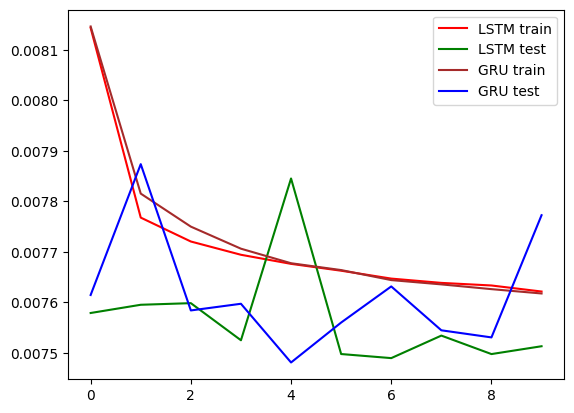

In [ ]:
# Loss
pyplot.plot(history_lstm.history['loss'], label='LSTM train', color='red')
pyplot.plot(history_lstm.history['val_loss'], label='LSTM test', color= 'green')
pyplot.plot(gru_history.history['loss'], label='GRU train', color='brown')
pyplot.plot(gru_history.history['val_loss'], label='GRU test', color='blue')
pyplot.legend()
pyplot.show()

In [ ]:
X_test.shape

(622578, 1, 7)

In [ ]:
yhat_test

array([[0.03960729],
       [0.01964899],
       [0.39357978],
       ...,
       [0.13071422],
       [0.20826401],
       [0.11461903]], dtype=float32)

In [ ]:
# Predictions with GRU model

# make a prediction
yhat_test = model_gru.predict(X_test)
X_test = X_test.reshape((X_test.shape[0], 7))

# invert scaling for forecast
print(yhat_test.shape, X_test.shape)
inv_yhat_test = np.concatenate((yhat_test, X_test[:, -6:]), axis=1)
print(inv_yhat_test.shape)
inv_yhat_test = scaler.inverse_transform(inv_yhat_test)
inv_yhat_test = inv_yhat_test[:,0]

19456/19456 [==============================] - 52s 3ms/step
(622578, 1) (622578, 7)
(622578, 7)


In [ ]:
# invert scaling for actual
y_test = y_test.values.reshape((len(y_test), 1))
inv_y = np.concatenate((y_test, X_test[:, -6:]), axis=1)
inv_y = scaler.inverse_transform(inv_y)
inv_y = inv_y[:,0]


In [ ]:
# calculate RMSE
rmse = np.sqrt(mean_squared_error(inv_y, inv_yhat_test))
print('Test RMSE: %.3f' % rmse)
#calculating the R2-score 
from sklearn.metrics import r2_score
r2=r2_score(inv_y,inv_yhat_test)
print('Test R2-Score: %.3f' %r2)
#calculating the MAE
from sklearn.metrics import mean_absolute_error
mae=mean_absolute_error(inv_y,inv_yhat_test)
print('Test MAE : %.3f' %mae)

Test RMSE: 0.263
Test R2-Score: 0.938
Test MAE : 0.086


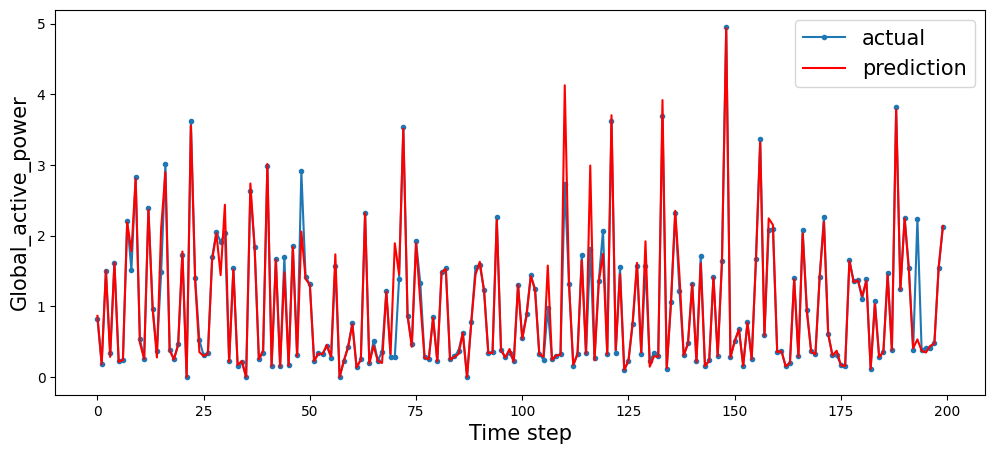

In [ ]:
# Compare predictions with actual values
## time steps, every step is one hour (you can easily convert the time step to the actual time index)
## for a demonstration purpose, I only compare the predictions in 200 hours. 
pyplot.figure(figsize=(12,5))
aa=[x for x in range(200)]
pyplot.plot(aa, inv_y[:200], marker='.', label="actual")
pyplot.plot(aa, inv_yhat_test[:200], 'r', label="prediction")
pyplot.ylabel('Global_active_power', size=15)
pyplot.xlabel('Time step', size=15)
pyplot.legend(fontsize=15)
pyplot.show()